In [1]:
import sys
sys.path.append("../../src")
import kibble_zurek as kz
import time_evolved_z_correlators as zz
from common_imports import *
from scipy.optimize import curve_fit
from numpy import gradient as grad

In [57]:
def grad2(y,x):
    return grad(grad(y,x),x)

In [149]:
xis = np.logspace(np.log10(1),np.log10(10),10)
taus = xis**2/8/pi/pi
print(taus)


[0.01266515 0.02112674 0.03524153 0.05878641 0.09806164 0.16357668
 0.27286234 0.45516182 0.75925567 1.2665148 ]


In [155]:
ns = np.arange(1,16+1)
states= [kz.state(400,tau,tau) for tau in taus]

In [156]:
ns = np.arange(1,15)
Kappas =[]
Ps = []
for s,t in zip(states,taus):
    print(t/taus[-1])
    kappas = [kz.P_n(ni+1,s)/kz.P_n(ni,s) for ni in ns]
    Kappas.append(kappas)
    Ps.append([kz.P_n(ni,s) for ni in ns])


0.01
0.01668100537200059
0.027825594022071253
0.0464158883361278
0.07742636826811271
0.12915496650148842
0.21544346900318836
0.35938136638046253
0.5994842503189408
1.0


In [158]:
def fit(tau,a,b,n):
    return a +b*exp(-n/(2*pi*sqrt(2*tau)))

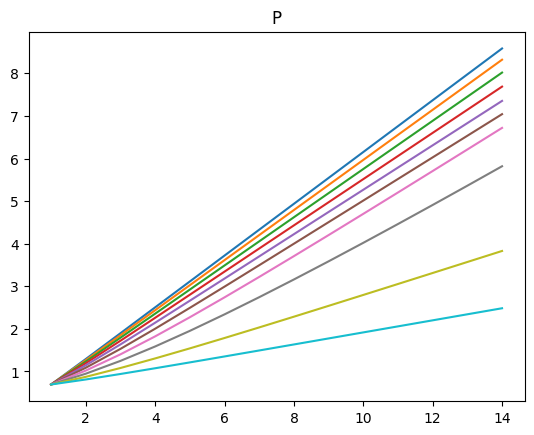

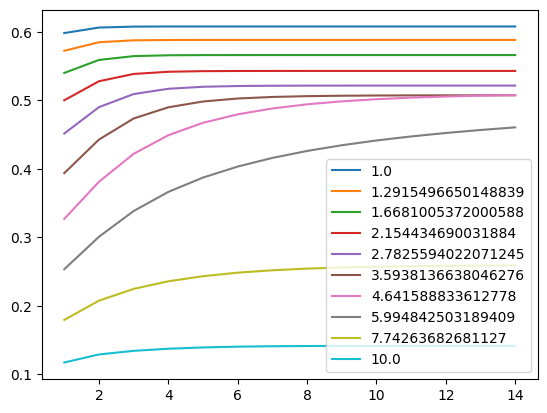

In [159]:
for P in Ps:
    plot(ns,-log(P))
title("P")
show()
for k,t in zip(Kappas,taus):
    plot(ns,-log(k),label=sqrt(2*t)*2*pi)
legend()

/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:644: ComplexWarning: Casting complex values to real discards the imaginary part
  a = asarray(a, dtype=dtype, order=order)


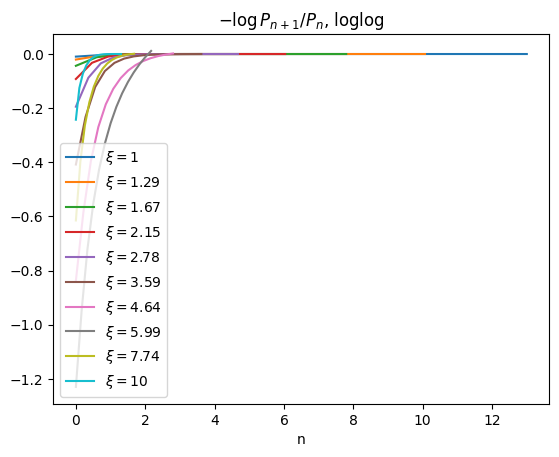

In [160]:
def fit_func(n, a, b, xi):
    return a + b*np.exp(-n/xi)

params = []
for k, t in zip(Kappas, taus):
    xi = 2*np.pi*np.sqrt(2*t)

    y = -log(k)
    popt, pcov = curve_fit(
       lambda n, a, b: fit_func(n, a, b, xi),
       ns,
       y
   )

    params.append(popt)
    a = np.mean(y[-2:])     # empirical kappa_infty from tail; no fit needed
    plt.plot((ns-1)/xi, (abs(y)-a)*xi, label=rf"$\xi={xi:.3g}$")
    #plt.scatter(ns, fit_func(ns, *popt, xi), s=5)

#yscale("log")
plt.xlabel("n")
plt.title(r"$-\log P_{n+1}/P_n$, loglog")
plt.legend(loc="lower left")
#loglog()
params = np.array(params)


Text(0.5, 0, '$\\xi$')

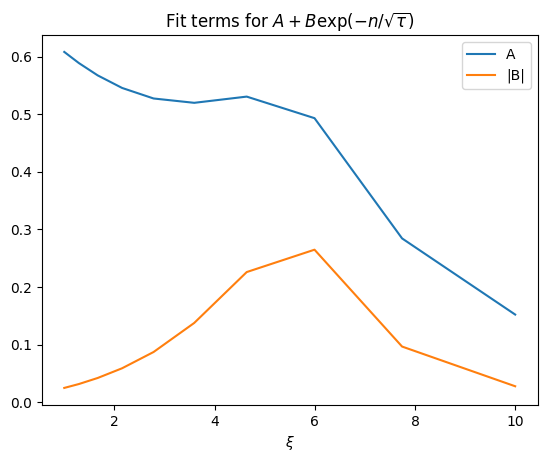

In [161]:
plot(xis,abs(params),label=["A","|B|"])
title(r"Fit terms for $A+B \exp(-n/ \sqrt{ \tau})$")
legend()
xlabel(r"$\xi$")
#plot(xis,xis)
#yscale("log")

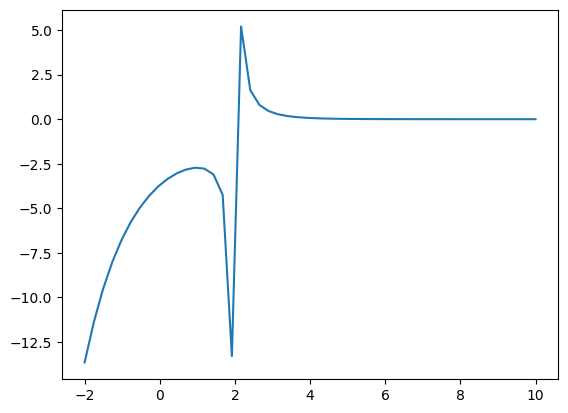

In [49]:
x= linspace(-2,10)
plot(x,exp(-(x-2))/(x-2))

[0.00018297 0.00166752]
[0.00127544 0.00602808]
[0.00323007 0.01133872]
[0.00502956 0.01461698]
[0.00450624 0.01142594]
[0.00402197 0.00918151]
[0.00578484 0.01214357]
[0.00534705 0.01047976]
[0.00392203 0.00725907]
[0.0031332  0.00552471]
[0.0025691  0.00434575]
[0.0010493  0.00171224]
[0.00069531 0.00109948]
[0.00270046 0.00415351]
[0.00357008 0.00535767]
[0.00113921 0.00167249]
[0.00024773 0.00035659]
[0.00271782 0.00384296]
[0.00179012 0.00249057]
[0.00083672 0.00114707]


/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:644: ComplexWarning: Casting complex values to real discards the imaginary part
  a = asarray(a, dtype=dtype, order=order)


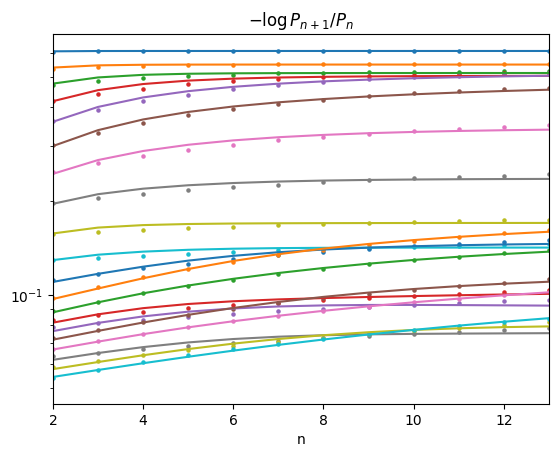

In [418]:
def fit_func(n, a, b, xi):
    return a -b*np.exp(-n/xi)

params = []
for k, t in zip(Kappas, taus):
    xi = 2*np.pi*np.sqrt(2*t)

    y = -log(array(k))
    popt, pcov = curve_fit(
       lambda n, a, b: fit_func(n, a, b, xi),
       ns,
       y
   )

    params.append(popt)

    plt.plot(ns, abs(y), label=rf"$\xi={xi:.3g}$")
    plt.scatter(ns, fit_func(ns, *popt, xi), s=5)
    print(sqrt(np.diag(pcov)))

yscale("log")
plt.xlabel("n")
plt.title(r"$-\log P_{n+1}/P_n$")
#plt.legend()
xlim(ns[1],ns[-1])
params = np.array(params)


[]

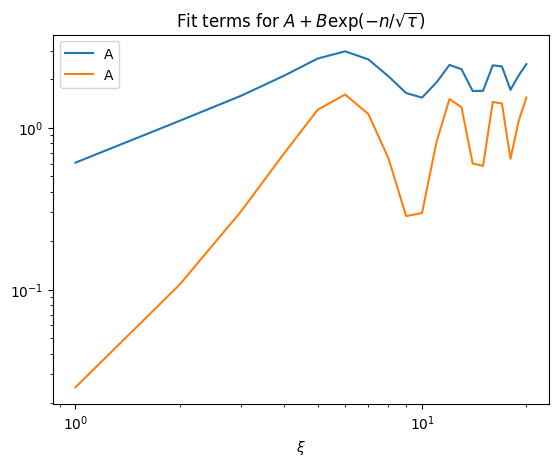

In [417]:
plot(xis,((params[:,0]))*xis,label=["A"])
plot(xis,((params[:,1]))*xis,label=["A"])

title(r"Fit terms for $A+B \exp(-n/ \sqrt{ \tau})$")
legend()
xlabel(r"$\xi$")
#plot(xis,xis)
loglog()

In [185]:
# tau is a scalar (e.g. tau = taus[i])

num = (
    8*(sqrt(2) - 2*pi*sqrt(taus))
    + (8*pi*cos(2*taus)*np.real(1/sqrt(taus*log(taus))))/abs(log(taus))
    - (pi*cos(2*taus)**2*(1 + np.sign(log(taus)))**2)
      /(4*taus**(3/2)*log(taus)**3)
)

den = (
    4*(
        sqrt(2)
        - 4*pi*sqrt(taus)
        + (pi*cos(2*taus)*np.real(1/sqrt(taus*log(taus))))/abs(log(taus))
    )
)

expr = num/den

expr = 1-1/2/sqrt(2)/pi/sqrt(taus)

[]

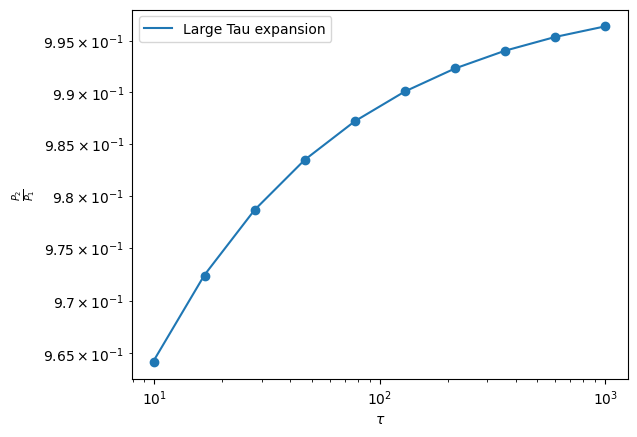

In [192]:
scatter(taus,check)
plot(taus,expr,label="Large Tau expansion")
legend()
xlabel(r"$\tau$")
ylabel(r"$\frac{P_2}{P_1}$")
loglog()

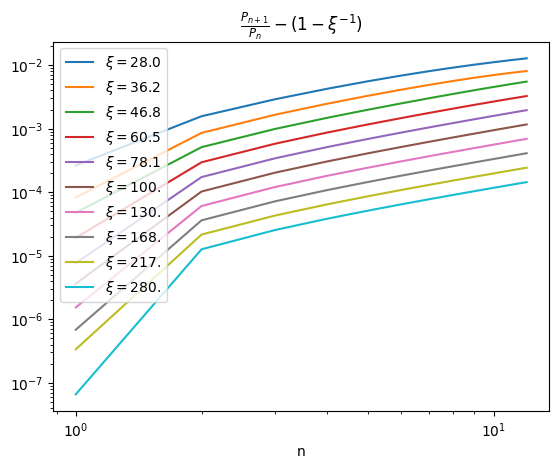

In [113]:
for p,t in zip(Ps,taus):
    xi = sqrt(2*t)*2*pi

    g = 1-1/xi

    plot(ns,abs(p-g),label=rf"$\xi= ${ str(xi)[:4]}")
title(r"$\frac{P_{n+1}}{P_{n}}-(1-\xi^{-1})$")
xlabel("n")
loglog()
legend()
#xlim(ns[1],ns[-1])
show()

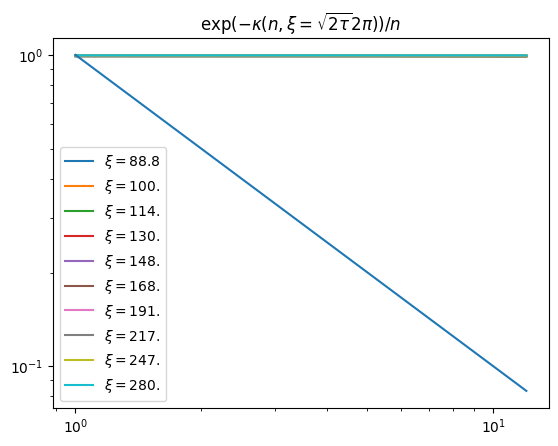

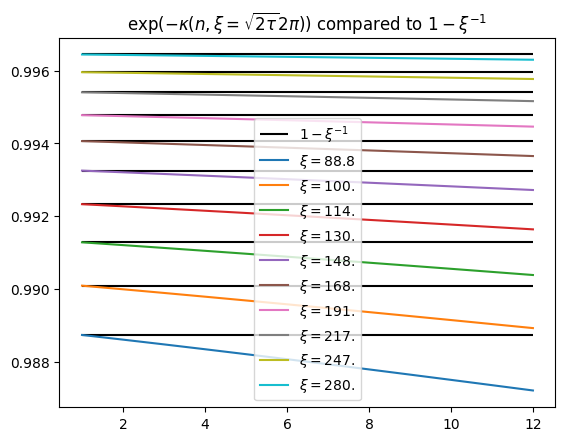

In [ ]:

for p,t in zip(Ps,taus):
    xi = sqrt(2*t)*2*pi

    if t==taus[0]:
      plt.hlines(1-1/xi,ns[0],ns[-1],color="black",label=r"$1-\xi^{-1}$")
    else:
      plt.hlines(1-1/xi,ns[0],ns[-1],color="black")

    plot(ns,p,label=rf"$\xi= ${ str(xi)[:4]}")
title(r"$\exp(- \kappa(n,\xi= \sqrt{2\tau}2\pi) )$ compared to $1-\xi^{-1}$")
legend()

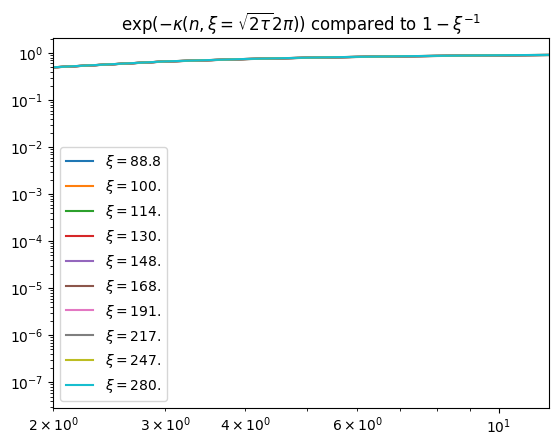

In [58]:
for p,t in zip(Ps,taus):
    xi = sqrt(2*t)*2*pi
    p =array(p)
    g = p-(1-1/xi)
    plot(ns,abs(p-(1-1/xi)/ns),label=rf"$\xi= ${ str(xi)[:4]}")
title(r"$\exp(- \kappa(n,\xi= \sqrt{2\tau}2\pi) )$ compared to $1-\xi^{-1}$")
xlim(ns[1],ns[-1])
loglog()
legend()

# nOT PAST HERE


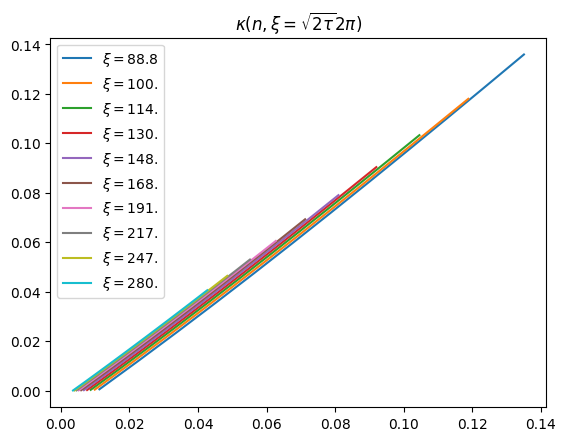

In [46]:
for p,t in zip(Ps,taus):
    p = array(p)
    xi = sqrt(2*t)*2*pi
    g = p-(1-1/xi)

    #plt.hlines(1-1/xi,ns[0],ns[-1],color="black")
    plot(ns/xi,abs(g)*xi,label=rf"$\xi= ${ str(xi)[:4]}")
title(r"$\kappa(n,\xi= \sqrt{2\tau}2\pi)$")
legend()

/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


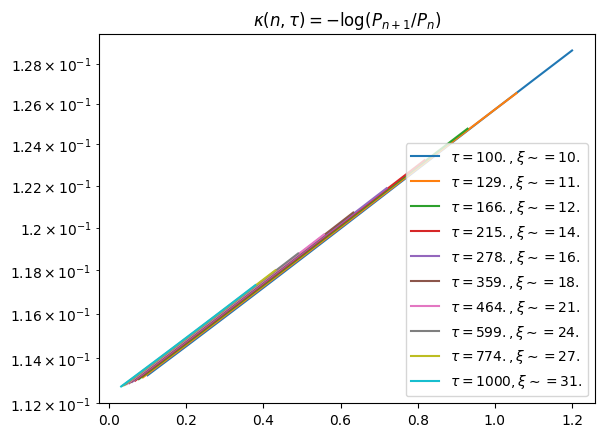

In [4]:
dat2=[]
for P,t in zip(Ps,taus):
    xi = sqrt(t)
    plot(ns/xi,-log(P)*xi,label=rf"$\tau={str(t)[:4]}, \xi \sim ={str(sqrt(t))[:3]}$")
    dat2.append(-log(P[-1]))
    #scatter(ns[-1],-log(P[-1]))
title(r"$\kappa(n,\tau) = -\log( P_{n+1}/P_n ) $")
legend()
yscale("log")


[]

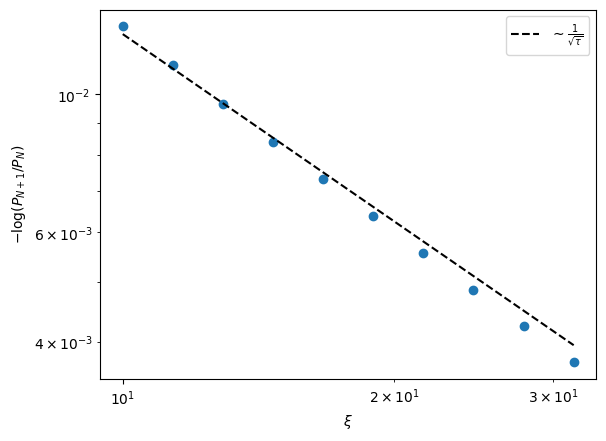

In [218]:
scatter(sqrt(taus),dat2)
plot(sqrt(taus),1/sqrt(taus)/8,"--k",label=r"$\sim \frac{1}{\sqrt{\tau}}$")
ylabel(r"$-\log(P_{N+1}/P_{N})$")
xlabel(r"$\xi$")
legend()
loglog()

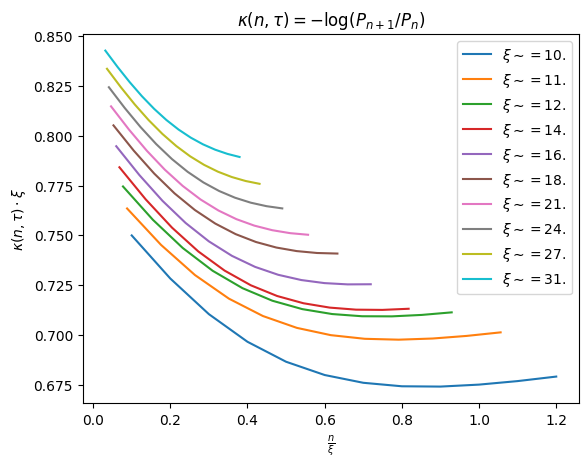

In [210]:
#dat2=[]
for P,t in zip(Ps,taus):
    plot(ns/sqrt(t)**1,-log(P)*
         sqrt(t)**(1/16),label=rf"$ \xi \sim ={str(sqrt(t))[:3]}$")
  #  dat2.append(-log(P[-1]))
    #scatter(ns[-1],-log(P[-1]))
xlabel(r"$\frac{n}{\xi}$")
ylabel(r"$\kappa(n,\tau) \cdot \xi $")
title(r"$\kappa(n,\tau) = -\log( P_{n+1}/P_n ) $")
legend()


In [113]:
rs = np.arange(1,100)

xxs = []
for s,t in zip(states,taus):
    xx= array([kz.sigma_general([0,r],s) for r in rs])
    xxs.append(xx)

/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


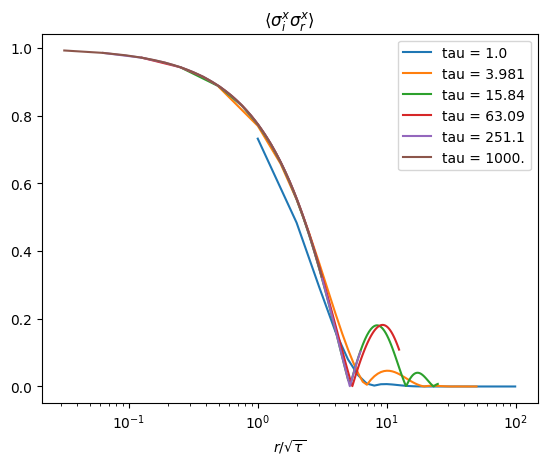

In [114]:

for xx,t in zip(xxs,taus):
    plot(rs/sqrt(t),abs(xx),label=f"tau = {str((t))[:5]}")
    #scatter(rs,exp(-rs/sqrt(t*pi*2)))
xlabel(r"$r/ \sqrt{\tau} $")
title(r"$\langle \sigma^x_i \sigma^x_r \rangle$")
#yscale("log")
legend()
#ylim()
xscale("log")

/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/0_correlation_length_withN/../../src/time_evolved_z_correlators.py:49: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = kz.D(-Nd,state)


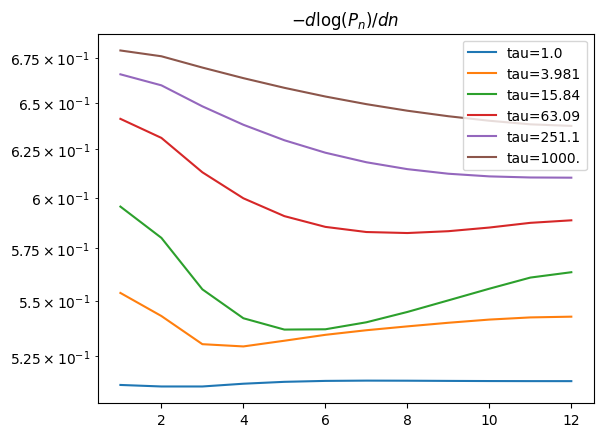

In [111]:
for s,t in zip(states,taus):
    P = [zz.P_n(ni,s) for ni in ns]
    plot(ns,np.gradient(-np.log(P),ns),label=f"tau={str(t)[:5]}")
title(r"$-d \log(P_n)/dn$ ")
yscale("log")
legend()

/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


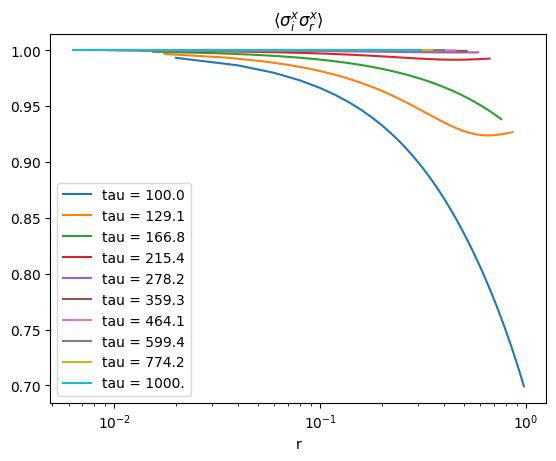

In [60]:
for s,t in zip(states,taus):
    xx= array([kz.sigma_general([0,r],s) for r in rs])
    plot(rs/sqrt(t)/sqrt(2 *pi)/2,xx,label=f"tau = {str((t))[:5]}")
xlabel("r")
title(r"$\langle \sigma^x_i \sigma^x_r \rangle$")
#yscale("log")
legend()
xscale("log")

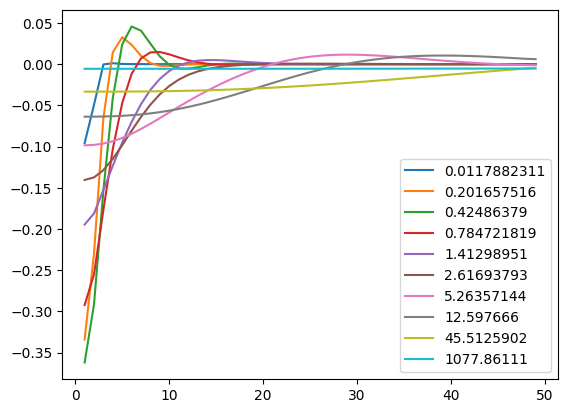

In [23]:
for s,t in zip(states,taus):
    xx= [kz.sigma_general([0,r],s) for r in rs]
    plot(rs,np.gradient(xx,rs),label=t)
#yscale("log")
legend()

In [151]:
import thermal_equilibrium as th
T = np.linspace(0,.2,10)
ns = np.arange(1,10)
dat=[]
g = 0.1
for ti in T:
    dat.append( [th.P_n(ni+1,300,g,ti)/th.P_n(ni,300,g,ti) for ni in ns])

dat=array(dat)

/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/0_correlation_length_withN/../../src/thermal_equilibrium.py:29: RuntimeWarning: divide by zero encountered in divide
  Dt  = (1 - g*exp(1j*k)) / eps * tanh(eps / T)


/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


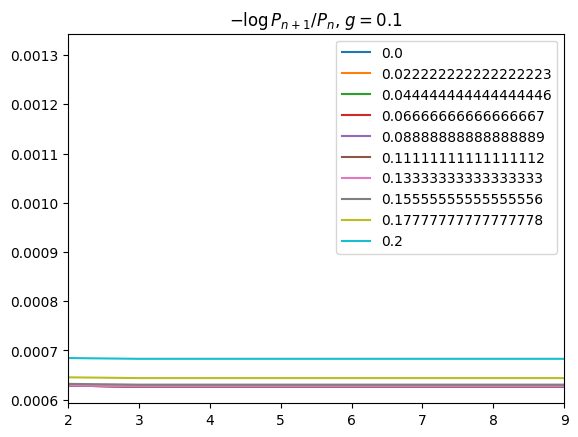

In [156]:
plot(ns,-log(dat.T),label=T)
title(r"$-\log{P_{n+1}/P_n}$," +fr" $ g={g}$")
xlim(ns[1],ns[-1])
#loglog()
legend()